# Applying Contemporary Deep Reinforcement Learning Methods to Bridge Bidding

## Abstract

Contract bridge is a multi-agent partially observable cooperative game played in partnerships. We focus on bridge bidding, where partners must exchange information and coordinate strategy through a constrained sequence of bids in competition with an opposing partnership, without any direct access to each other's cards. Recent advances in deep reinforcement learning have demonstrated that strong bidding agents can be trained purely through self-play (Gong et al., 2019; Kita et al., 2024). However, both approaches treat partner-hand estimation as an implicit function of a simple policy network. We investigate whether incorporating a belief-augmented agent, together with deep learning architecture advances, provides gains against a belief-free baseline. All experiments are conducted at reduced computational scale using the open-source `brl` environment from Kita et al. (2024) and the `pgx` environment encoding, with performance measured in IMPs per board against the Kita et al. baseline. Our results provide empirical insight into whether explicit Bayesian belief modelling and network modifications offer practical benefits over implicit representations in partnership bridge bidding.


## 1. Introduction

### 1.1 Games as RL benchmarks

Games are central to reinforcement learning research, providing well-defined rules and clear performance metrics along with interesting and scalable challenges. Early successes in perfect-information settings, such as TD-Gammon's backgammon mastery through temporal-difference learning (Tesauro, 1995), Deep Blue's defeat of the world chess champion (Campbell et al., 2002), and AlphaGo's landmark victory in Go (Silver et al., 2016), demonstrated that learned agents could surpass human expert performance through a combination of deep neural networks and tree search. AlphaZero subsequently generalised this approach, mastering chess, shogi, and Go through pure self-play without human domain knowledge (Silver et al., 2018).

Attention has since shifted towards imperfect-information games, which introduce the additional complexity of hidden state and require agents to reason under uncertainty. In two-player zero-sum settings, DeepStack (Moravčík et al., 2017) and Libratus (Brown and Sandholm, 2018) both achieved superhuman performance in heads-up no-limit Texas Hold'em poker, with Pluribus (Brown and Sandholm, 2019) later extending this success to the multi-player case. Suphx (Li et al., 2020) achieved master-level performance in Mahjong using deep reinforcement learning, and DouZero (Zha et al., 2021) mastered the Chinese card game Dou Di Zhu through self-play. Hanabi (Bard et al., 2020) has emerged as a particularly important benchmark for cooperative partial-information play, since agents must infer partners' private hands from the history of public actions alone.

### 1.2 Contract bridge background

Contract bridge is a four-player trick-taking card game in which partnerships of two compete against each other. The standard 52-card deck is divided among the four players (13 cards each). The game consists of two main phases: the **bidding** (setting a contract) and the **play** (trying to achieve the contract).

We will not outline the rules of trick-taking during the play, since our work focuses on bidding only. The playing phase has been largely addressed by existing models, while bidding remains the decisive and unsolved challenge. GIB (Ginsberg, 1999), the first expert-level bridge program, demonstrated early strong play results using Monte Carlo search methods and remains an excellent benchmark even today.

The challenge of the bidding is to find an optimal contract (through the bids) for a partnership while each actor knows only their own cards and the public sequence of bids. Unlike poker, where the strategic goal is adversarial, bridge bidding requires cooperative communication: partners must infer the best attainable contract from their joint holdings. Communication through bids is central to bidding but poses unique difficulties. The bidding process is naturally hierarchical — once actors (or adversaries) make higher bids, the communication state space becomes constrained. Bids are therefore multi-purpose: they can implicitly suggest a desired contract (or holding of cards), exchange specific information between partners, and interfere with opponents' communication. Hence, the language needs to be flexible; actions can very often have imperfect outcomes, making it complex for traditional algorithms to learn.

For humans, there are several template bidding systems that partnerships can follow: Standard American Yellow Card (SAYC), Acol, Precision, etc. However, partnerships typically hone their agreements and make numerous modifications to these systems (expert system documents can be notoriously lengthy). Rather than rule-based specification for the algorithm, we follow the approach of self-play with a supervised warm start to allow the algorithm to learn its own variant of a system (detailed in the methodology section). During tournaments, there are specific rules for disclosure of bidding systems and legal actions; however, we do not explore this topic in this paper, as the intention is to design a model flexible enough to play against various systems.

## 2. Background and Related Work

### 2.1 Rule-based approaches

Early computational approaches to bridge bidding relied heavily on human-designed rules and hand-crafted feature representations. GIB (Ginsberg, 1999) developed a rule-based system based on existing bidding structures, and Ventos et al. (2017) attempted to boost bridge AI performance by combining such rule-based systems with learned components, but remained dependent on human knowledge.

WBridge5, developed by Yves Costel and a multiple-time winner of the World Computer-Bridge Championship (2005, 2007, 2008, and 2016–2018), implements a sophisticated human-designed bidding system and has become the standard benchmark against which learned bridge agents are evaluated, with performance typically reported in International Match Points (IMPs) per board.

### 2.2 Deep RL approaches

The first application of deep reinforcement learning to bridge bidding was by Yeh, Hsieh, and Lin (2018), who proposed learning a bidding policy directly from raw card features without relying on human-designed conventions. Their key technical contribution was the Penetrative Bellman Equation, a modification of standard Q-learning designed to propagate reward signals across the partial-information boundary. Their results showed performance competitive with WBridge5, despite being restricted to the non-competitive bidding setting (where opponents always pass) and reliant on a fixed number of bidding turns.

Rong, Qin, and An (2019) introduced a competitive bidding system based on deep neural networks that addressed imperfect information more directly. Their architecture paired a Policy Network (PNN) with an Estimation Network (ENN) that inferred the distribution of partner and opponent cards from the bidding history. The system was trained through a combination of supervised learning on expert human data and REINFORCE-based self-play, outperforming WBridge5 by 0.25 IMPs per board.

Gong et al. (2019) established that end-to-end training without human knowledge is both feasible and competitive, beating WBridge5 by 0.41 IMPs. Their central empirical finding was that a compact bidding history representation combined with careful self-play was sufficient for the agent to develop an implicit communication protocol. Lockhart et al. (2020) tackled the distinct but related problem of human–agent cooperation in bridge bidding, training an agent that could partner effectively with human players using WBridge5 as a proxy.

### 2.3 Kita et al. foundation

Kita et al. (2024) then established the current state of the art by showing that a straightforward combination of supervised-learning pretraining, PPO fine-tuning, and Fictitious Self-Play outperforms WBridge5 at the highest difficulty by a significant margin (1.24 IMPs per board).

Kita et al. released their full pipeline as open-source software (the `brl` environment, built on `pgx`), providing the reproducible foundation on which the present work is built. Interestingly, despite approaching the problem from a pure reinforcement learning angle without any bridge-specific information encoding, they achieve impressive results. We detail the modifications of the network, training, representations and evaluations in the sections below.


## 3. Transformer Policy Network

### 3.1 Motivation

The baseline policy network used by Kita et al. (2024) maps the 480-dimensional binary observation vector directly to bid logits through a four-layer MLP with 1024 hidden units per layer. While this architecture achieves strong performance, it treats the entire observation as a flat, unstructured vector, every input bit is therefore processed with fixed, position-independent weights regardless of its semantic role in the auction.

This design choice ignores a fundamental property of bridge bidding: the auction is inherently sequential and relational. In bridge, the meaning of any individual bid cannot be interpreted in isolation, for example, a 2H opening bid carries entirely different strategic information depending on whether it is made in first seat before any other bids, or in response to a 1NT opener after two passes. The relationship between bids, their positions in the auction, and the players who made them are all critical to understanding the current game state.

The Transformer architecture (Vaswani et al., 2017), originally developed for natural language processing, is designed precisely for this class of problem. Its core mechanism of scaled dot-product self-attention computes pairwise interactions between all elements of an input sequence simultaneously, allowing each element to attend to all others when forming its representation. This is analogous to how an expert bridge player reads an auction: not by processing each bid independently, but by considering how each bid relates to the full preceding exchange between all four players.

This inductive bias makes Transformers a natural fit for the bidding history representation. Rather than relying on the MLP to implicitly learn positional dependencies through weight magnitude alone which requires the network to discover and encode sequential structure from scratch, self-attention provides an explicit architectural mechanism for modelling these dependencies. Prior work in sequential decision-making has demonstrated that Transformer-based policy networks can outperform MLP baselines in settings where the observation has meaningful sequential structure, including card games (Zha et al., 2021) and multi-agent coordination tasks (Wen et al., 2022).

We therefore propose replacing the DeepMind MLP policy network with a Transformer encoder as the policy and value backbone, whilst keeping all other components of the Kita et al. pipeline unchanged. Specifically the PPO training algorithm, the DDS reward oracle, and the pgx bridge environment. This constitutes a controlled architectural ablation that isolates the contribution of the representation to bidding performance.

### 3.2 Architecture

The proposed architecture, which we refer to as BridgeTransformer, is a Transformer encoder network that serves as both the policy and value function approximator within the PPO framework. It takes the 480-dimensional binary observation vector as input and outputs a vector of 38 bid logits alongside a scalar state value estimate.

**Input Representation**

The 480-dimensional observation vector is decomposed into three semantically distinct components before being fed into the network:

- **Hand representation (bits 0–51):** A 52-bit binary vector encoding the agent's private cards, one bit per card in the standard deck.
- **Vulnerability context (bits 52–59):** An 8-bit binary vector encoding the vulnerability state of each partnership, which determines scoring multipliers and therefore influences optimal bidding strategy.
- **Bidding history (bits 60–479):** A 420-bit binary vector encoding the full sequence of bids made so far in the auction.

The key architectural decision concerns how the bidding history is processed. Rather than feeding all 420 bits as a flat vector, we reshape this into a sequence of 35 tokens of 12 features each. Each token corresponds to one of the 35 possible contract bid slots in bridge (7 levels × 5 denominations), and its 12 features encode which players have bid at that slot and what actions were taken. This tokenisation imposes meaningful sequential structure on the bidding history, giving the Transformer a natural sequence to attend over.

**Transformer Encoder**

Each token is first projected from 12 dimensions to the model dimension $d_{\text{model}}=256$ via a learned linear layer. Learned positional embeddings of the same dimension are then added to each token, allowing the model to distinguish the position of each bid slot within the auction sequence. The sequence of embedded tokens is then passed through 3 Transformer encoder layers, each consisting of:

- **Multi-head self-attention** with 8 attention heads, key size $d_{\text{model}}/\text{num\_heads}=32$. This allows the model to jointly attend to information from different representation subspaces at different positions (Vaswani et al., 2017).
- **Position-wise feed-forward network** with inner dimension $4 \times d_{\text{model}}=1024$, using ReLU activation.
- **Residual connections** and **Layer Normalisation** after each sub-layer, following the Post-LN convention.

**Pooling and Output Heads**

After the Transformer encoder, the 35 token representations are aggregated via mean pooling across the sequence dimension, producing a single 256-dimensional vector summarising the auction. This is then concatenated with the hand and vulnerability vectors, giving a combined representation of dimension $256+52+8=316$. A final linear projection maps this to dimension 256 with ReLU activation, before two separate linear output heads produce:

- **Policy logits:** a vector of dimension 38 (35 contract bids + Pass + Double + Redouble), from which the action distribution is derived via softmax masking over legal actions.
- **Value estimate:** a scalar, used by PPO as the baseline for advantage estimation.

The full architecture contains approximately 2.47 million parameters, compared to the DeepMind MLP baseline's 3.7 million, making it a leaner model despite its greater representational expressiveness.

A schematic of the architecture is shown below, followed by the core __call__ method of the implementation: 

```python

def __call__(self, x):
        # we split the 480 dims into meaningful parts using the ellipsis operator, making sure we conserve other dimensions
        #we do this split because the hand and context are global features that dont vary across the 35bid slots
        #The history feature does vary across the bid slots and is sequential in nature so we need to seperate
        #before attention in order to help the model attend to meaningful sequence information
        hand    = x[..., :52]       # (batch, 52)  — the 13 cards of the player
        context = x[..., 52:60]     # (batch, 8)   — vulnerability(yes/no) + pre-opening passes
        history = x[..., 60:]       # (batch, 420) — the bidding history
        # we now reshape the bid history into tokens
        # (batch, 420) to a two dimensional vector corresponding to each bid slot and its 12 features (batch, 35, 12)
        #the 12 features being; (was this slot bid on? was it doubled? was it redoubled?) AND by who? (=3*4=12)
        batch_shape = x.shape[:-1]   # (batch,) or () if unbatched
        tokens = history.reshape(*batch_shape, 35, 12)
        #We project each token from 12 dims to d_model dims using a fully connected linear layer
        tokens = hk.Linear(self.d_model)(tokens)

        #Now we add learned positional encodings using an embedding layer (this will allow the model to learn meaningful positional information/develop strategies based on position)
        pos_indices = jnp.arange(35)
        pos_embeddings = hk.Embed(35, self.d_model)(pos_indices)
        # pos_embeddings shape: (35, d_model)
        tokens = tokens + pos_embeddings
        # shape still: (batch, 35, d_model)

        # We can now apply transformer layers
        for i in range(self.num_layers):
            tokens = self._attention_block(tokens, layer_idx=i)
        # shape remains unchanged

        # use mean pool to average over all 35 tokens to prepare it for the MLP
        seq_repr = jnp.mean(tokens, axis=-2)

        # We concatenate global features with our sequentic history features
        combined = jnp.concatenate([seq_repr, hand, context], axis=-1)

        #Finally we pass the features through a shared MLP to learn non-linear patterns for global and sequential features together
        combined = hk.Linear(self.d_model)(combined)
        combined = jax.nn.relu(combined)

        #Final step= output heads
        #Policy head, Actor maps to 38 logits, 1 for every possible action
        logits = hk.Linear(self.action_dim)(combined)
        #Value head, maps to a single scalar, the Critic's estimated reward
        value  = hk.Linear(1)(combined)

        return logits, jnp.squeeze(value, axis=-1)
```

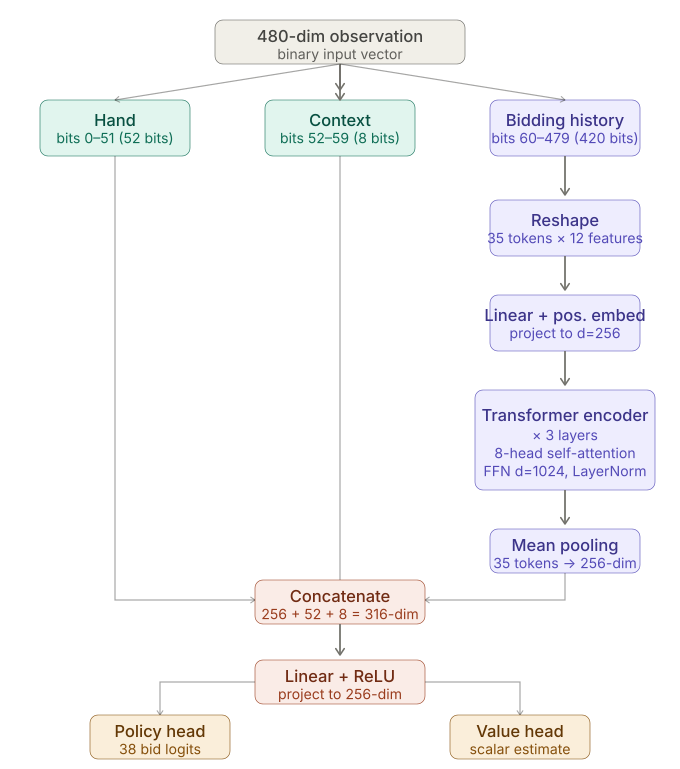

In [10]:
from IPython.display import SVG, display
display(SVG(filename="Transformer Architecture/results/bridge_transformer_architecture.svg"))

The model is implemented using DeepMind Haiku (Hennigan et al., 2020), a functional neural network library built on JAX (Bradbury et al., 2018) that transforms neural network code into pure functions compatible with JAX's JIT compilation and automatic differentiation. This choice is inherited from the Kita et al. codebase and ensures full compatibility with the existing PPO training pipeline. 

### 3.3 Input Representation

As mentioned in 3.2, a critical design decision in applying the Transformer to bridge bidding is how to structure the 480-dimensional binary observation vector into a form that the architecture can exploit. Indeed the Transformer's self-attention mechanism operates over a sequence of tokens and it has no built-in mechanism for processing a flat vector. The input must therefore be decomposed and structured before being passed to the encoder.

#### Decomposition into semantic components

* **Hand representation (bits 0–51):** A 52-bit one-hot vector with one bit per card in the standard deck. A value of 1 at position $i$ indicates that the agent holds card $i$. This encodes the agent's private information, this is the only component of the game state that is hidden from opponents.

* **Vulnerability context (bits 52–59):** An 8-bit binary vector encoding the vulnerability status of each partnership. In bridge, a vulnerable partnership faces higher penalties for failing a contract but also receives higher rewards for making one. Vulnerability therefore directly influences optimal bidding strategy and must be explicitly represented.

* **Bidding history (bits 60–479):** A 420-bit binary vector encoding the complete sequence of bids made so far in the auction, across all four players. This is the component that carries the most relational structure, and is the primary motivation for using a Transformer.

#### Tokenising the bidding history

Rather than feeding the 420-bit history as a flat vector, we reshape it into a sequence of 35 tokens of 12 features each. The 35 tokens correspond to the 35 possible contract bids in bridge: 7 bidding levels (1 through 7) multiplied by 5 denominations (Clubs, Diamonds, Hearts, Spades, No Trump). For each of these 35 bid slots, the 12 associated features encode information about which players have acted at that level and what those actions were, capturing the full auction context in a structured way.

This tokenisation is motivated by the hierarchical nature of bridge bidding. The auction proceeds strictly upward through the 35 contract levels which means once a higher contract has been bid, lower ones are no longer available. Each token therefore represents a distinct decision point in the auction hierarchy, and the relationships between tokens; who bid what at which level relative to other bids, are precisely the dependencies that self-attention is designed to model.

#### Positional encoding

Unlike the original Transformer for language (Vaswani et al., 2017), which uses fixed sinusoidal positional encodings, we use learned positional embeddings. This is a separate embedding table of shape $(35, d_{\text{model}})$ that assigns each of the 35 token positions a trainable 256-dimensional vector. These embeddings are added to the token projections before being passed to the encoder, allowing the model to learn position-specific representations that are optimised for the bridge auction structure rather than relying on a hand-crafted encoding scheme. Learned positional embeddings have been shown to perform comparably or better than fixed encodings in domains with structured, finite-length sequences (Gehring et al., 2017).

#### Hand and context integration

The hand and vulnerability vectors are deliberately kept separate from the token sequence and are not passed through the Transformer encoder. This is a conscious design choice: self-attention over the bidding history tokens is the core representational mechanism, and mixing the private hand bits into the sequence would mix-up two fundamentally different types of information: public auction history and private card holdings. Instead, the hand and vulnerability vectors are concatenated with the pooled sequence representation after the encoder, at which point a final linear layer integrates all three components before the output heads. This mirrors the separation of public and private information that is fundamental to the game itself.

### 3.4 Compatibility Engineering

Integrating the BridgeTransformer into the existing `brl` from the Kita et al. github codebase required resolving several compatibility issues arising from version mismatches between the original repository and the software environment required to run it on modern hardware. These changes are documented here both for reproducibility and because they represent a non-trivial contribution, the original codebase was not runnable without them.

#### Environment versioning

The original Kita et al. repository was built against older versions of JAX and pgx that are incompatible with current CUDA drivers and GPU hardware. After systematic debugging, the following pinned versions were established as the minimal working configuration:

| Package | Pinned version | Reason |
|---|---|---|
| `jax[cuda12]` | 0.4.35 | Compatible with modern CUDA 12 drivers |
| `nvidia-cuda-nvcc-cu12` | 12.6.77 | Prevents compiler version conflicts during JAX compilation |
| `dm-haiku` | 0.0.16 | Matches parameter namespace expected by existing pkl files |
| `pgx` | 2.4.0 | Required for GPU compatibility; introduces breaking API changes |
| `setuptools` | 69.5.1 | Prevents `wandb` crash on Python 3.12+ due to missing `pkg_resources` |

Full installation instructions are provided in the Appendix 7.1. 

#### pgx 2.x environment wrapper rewrite

The most significant compatibility change concerned `Transformer Architecture/src/utils.py`. In pgx version 1.x, the environment state object exposed an internal attribute `state._rng_key` that was used throughout the codebase to manage random number generation during environment steps. This attribute was removed entirely in pgx 2.x as part of an API redesign that made the environment fully stateless with respect to random keys.

The `auto_reset` wrapper and all associated step functions in `Transformer Architecture/src/utils.py` were rewritten to pass the random key explicitly at each call, rather than retrieving it from the state object. This required threading the PRNG key through the rollout loop in `Transformer Architecture/src/ppo.py` and ensuring that key splitting was handled correctly at each environment step to maintain reproducibility. The change is backwards-compatible meaning that the rewritten wrappers produce identical behaviour to the original under pgx 1.x semantics.

#### Supervised learning forward pass fix

The original `sl.py` used a custom Haiku transform that produced a parameter namespace incompatible with the one expected by `ppo.py` when loading a pre-trained model as a warm-start. Specifically, the parameter dictionary keys produced by the SL training script did not match the keys that `ppo.py` expected when initialising the actor network from a saved checkpoint.

This was resolved by refactoring `sl.py` to use the shared `make_forward_pass` function defined in `Transformer Architecture/src/models.py`, which is the same function used by `ppo.py`. This ensures that parameters saved during SL training can be loaded directly by the PPO training loop without any key remapping, and that the pkl file format is consistent across both scripts.

#### PPO evaluation model type fix

A bug was identified in the `simple_duplicate_evaluate` function in `Transformer Architecture/src/ppo.py`, where the opponent model in evaluation was incorrectly instantiated using `actor_model_type` rather than `eval_opp_model_type`. This meant that when evaluating a Transformer actor against a DeepMind MLP opponent, both teams were inadvertently using the Transformer architecture, producing misleading evaluation metrics during training. The fix ensures each team uses its correct model type during evaluation, which is essential for meaningful comparison between architectures.

#### Adding Transformer as a valid model type

Finally, the string literal `"Transformer"` was added as a valid option in all relevant `Literal` type annotations across `ppo.py` and `sl.py`, and the corresponding instantiation logic was added to `make_forward_pass` in `Transformer Architecture/src/models.py`. Without this, passing `actor_model_type=Transformer` on the command line would raise a validation error before any training began.

All changes are available in the fork at [github.com/ruben728/brl](https://github.com/ruben728/brl), with the full diff relative to the original `harukaki/brl` repository visible in the commit history. The full explanation for this is located in Appendix 7.1.

### 3.5 Supervised Learning Warm-Start

Training a bridge bidding agent from random initialisation via reinforcement learning alone is known to be extremely slow and unstable, due to the sparse and delayed nature of the reward signal in bridge. A full auction must complete before any reward is observed, and randomly initialised policies produce largely illegal or nonsensical bid sequences that yield no useful gradient signal. Following Kita et al. (2024) and the broader literature on RL for games (Silver et al., 2016), we therefore initialise all policy networks via supervised learning on human expert data before beginning RL training. This warm-start provides each network with a meaningful prior over legal, sensible bidding behaviour, from which RL fine-tuning can then improve performance through self-play.

#### Data

The supervised learning dataset consists of bridge deal records from the OpenSpiel bridge dataset (Lanctot et al., 2019), accessed via Google Cloud Storage. The dataset contains expert-level bidding sequences paired with the corresponding deal configurations providing ground-truth bid labels for imitation learning. The training split contains approximately 10 million labelled bidding decisions, providing broad coverage of the space of possible auction states.

#### Training procedure

The SL warm-start is formulated as a standard multi-class classification problem: given the current observation vector, predict the correct next bid from the 38 possible actions. The network is trained to minimise cross-entropy loss between the predicted logit distribution and the one-hot ground-truth bid label. Both the policy and value heads are present during SL training and trained jointly via `make_forward_pass`, the shared forward pass function used by both `sl.py` and `ppo.py`. This ensures parameter namespace compatibility when loading the warm-start checkpoint into the PPO training loop.

Both warm-starts were trained with identical hyperparameters: 100,000 iterations, batch size 128, learning rate 0.0001, using the Adam optimiser (Kingma and Ba, 2015). These hyperparameters follow Kita et al. (2024) directly and were not tuned further, since the primary goal of the warm-start is to produce a reasonable initialisation rather than a maximally accurate imitation policy.

### 3.5.1 Transformer SL warm-start

The Transformer warm-start trains BridgeTransformer on the OpenSpiel dataset and produces the checkpoint `sl_model_transformer/model_final.pkl`, which serves as the initialisation point for the Transformer RL training in section 3.6. The training command is as follows:

```python
!python sl.py \
    iterations=100000 \
    train_batch=128 \
    learning_rate=0.0001 \
    eval_every=10000 \
    data_path="bridge_data" \
    save_path="sl_model_transformer" \
    type_of_model=Transformer \
    track=False
```

<img src="Transformer Architecture/results/sl_mlp_accuracy.png" width="600"/>

The accuracy curve shows consistent, monotonic improvement throughout training with no signs of overfitting or instability. Crucially, no bid collapse behaviour was observed during SL training.

### 3.5.2 DeepMind MLP SL warm-start

An equivalent warm-start was trained for the DeepMind MLP architecture, producing the checkpoint `sl_model_deepmind/model_final.pkl`. This checkpoint serves a dual purpose in our experimental setup: it is used as the fixed opponent during Transformer RL training, and as the initialisation point for the MLP baseline RL run used in the head-to-head evaluation. Training used the same hyperparameters and dataset as the Transformer warm-start:

```python
!python sl.py \
    iterations=100000 \
    train_batch=128 \
    learning_rate=0.0001 \
    eval_every=10000 \
    data_path="bridge_data" \
    save_path="sl_model_deepmind" \
    type_of_model=DeepMind \
    track=False
```

<img src="Transformer Architecture/results/sl_transformer_accuracy.png" width="600"/>

<img src="Transformer Architecture/results/sl_comparison.png" width="600"/>

The Transformer warm-start reached a final test accuracy of 87.9% after 100,000 training steps, while the DeepMind MLP warm-start reached 90.4% over the same training period. Despite this modest gap, both warm-starts reach strong absolute accuracy, confirming that both architectures are capable of learning a strong imitation prior from the same dataset. This near-parity at the SL stage provides a controlled starting point for the RL comparison meaning that any performance differences observed during RL training can therefore be attributed to the RL training dynamics and architectural properties rather than differences in warm-start quality. This was further validated by head-to-head evaluation between the two SL models, which showed comparable performance in direct play. 

### 3.6 Reinforcement Learning Training

Following the supervised learning warm-start, the BridgeTransformer policy is fine-tuned using Proximal Policy Optimisation (PPO), a widely adopted on-policy actor-critic algorithm that has demonstrated strong performance across a range of sequential decision-making tasks (Schulman et al., 2017). PPO optimises the policy by maximising a clipped surrogate objective that prevents excessively large policy updates, stabilising training in environments with sparse or noisy reward signals, both of which characterise bridge bidding.

#### Reward signal

Following Kita et al. (2024), the reward signal is provided by a Double Dummy Solver (DDS), which computes the optimal number of tricks achievable for any given deal assuming all four hands are visible. This provides a theoretically grounded upper bound on trick-taking performance and allows the agent to receive a meaningful reward at the end of each auction without requiring a full card-play simulation. The DDS reward is converted to International Match Points (IMPs) using the standard WBF scoring table, which is the evaluation currency used throughout bridge AI research. IMP scoring is non-linear as it rewards accurately bidding makeable games and punishes more than partscore contracts. Therefore it directly incentivises the agent to learn strategically meaningful bidding rather than merely legal bidding.

#### Training setup

The Transformer RL training uses the following configuration, which follows Kita et al. (2024) at reduced computational scale to fit within our hardware budget:

| Parameter | Value | Justification |
|---|---|---|
| `total_timesteps` | 200,000,000 | 10% of paper's 2B; sufficient to show clear learning trends |
| `num_envs` | 1,024 | 8× fewer than paper's 8,192; maintains sufficient parallelism |
| `num_steps` | 32 | Identical to paper |
| `update_epochs` | 10 | Identical to paper |
| `minibatch_size` | 512 | Halved to match reduced `num_envs` |
| `lr` | 1×10⁻⁶ | Identical to paper |
| `ent_coef` | 0.001 | Identical to paper; entropy regularisation weight |
| `gamma` | 1.0 | No discounting — bridge auctions are short-horizon |
| `gae_lambda` | 0.95 | Standard GAE parameter (Schulman et al., 2016) |


Each PPO update collects a rollout batch of `num_envs × num_steps = 1,024 × 32 = 32,768` environment transitions, then performs `update_epochs × (batch_size / minibatch_size)` gradient steps on that batch before discarding it. Over the full training run this yields:

$$\text{total updates} = \frac{\text{total\_timesteps}}{\text{num\_envs} \times \text{num\_steps}} = \frac{200{,}000{,}000}{32{,}768} \approx 6{,}103 \text{ PPO iterations}$$

#### Opponent and initialisation

Three training modes are available in the `brl` framework, each with different implications for how the policy learns cooperative bidding conventions:

* **Fixed opponent training (`self_play=False`):** the actor trains against a frozen checkpoint that never updates. This provides a stable learning target but means the two partners cannot co-evolve a shared bidding language, the actor must learn to communicate with a partner that is not adapting to it.

* **Self-play (`self_play=True`):** the actor trains against a copy of its own current weights, updated in parallel. Both partners share the same architecture and co-evolve together, allowing a shared bidding system to emerge naturally.

* **Fictitious Self-Play (FSP):** the opponent is sampled from a historical pool of past policy snapshots rather than just the current policy. This is the training mode used by Kita et al. (2024), and is the key reason behind their strong results. FSP encourages the actor to develop conventions that are robust across a range of opponent skill levels rather than over-adapting to a single fixed target.

Due to computational constraints, we use `self_play=False` throughout. FSP requires maintaining and continuously sampling from a historical pool of checkpoints, which significantly increases memory and storage overhead beyond what our hardware budget allowed. This is a deliberate and acknowledged simplification from the Kita et al. setup, and means that our results are not directly comparable to theirs. The training signal our agent receives is fundamentally different from the co-evolutionary signal that drives their strong performance.

To ensure a fair internal comparison between architectures, we retrained the DeepMind MLP baseline under the identical fixed-opponent setup using the same hyperparameters, the same opponent checkpoint and the same number of steps. This means that while our absolute IMP scores cannot be compared to Kita et al.'s published results, the relative comparison between our Transformer and our MLP baseline is controlled.

The Transformer actor is initialised from the pre-trained Transformer SL warm-start (`sl_model_transformer/model_final.pkl`), and the fixed opponent is the pre-trained DeepMind MLP SL warm-start (`sl_model_deepmind/model_final.pkl`). Both checkpoints are loaded via the shared `make_forward_pass` interface described in section 3.4.

#### Checkpointing and infrastructure

Model checkpoints are saved every 50 PPO iterations to `rl_log/transformer_full/rl_params/`, producing approximately 122 checkpoint files over the full training run. All training metrics; IMP scores, policy entropy, KL divergence, and loss components, are logged to `training_output.log` at every iteration and subsequently extracted to `results/transformer/metrics.csv` for analysis.

Training was conducted on an NVIDIA RTX A6000 (48GB VRAM) instance via ThunderCompute, and ran for approximately 62 hours. 
**The full training command and folder structure in sections 3.5 and 3.6 is described with regards to the fork created at [github.com/ruben728/brl](https://github.com/ruben728/brl), for clarity purposes the full pipeline was not added to the github classroom repo. A full description of how to reproduce our results is given in Appendix 7.1**. Training was launched using `nohup` to ensure the process persisted across SSH disconnections:

```bash
nohup python ppo.py \
    actor_model_type=Transformer \
    self_play=False \
    opp_model_type=DeepMind \
    opp_model_path="sl_model_deepmind/model_final.pkl" \
    num_envs=1024 \
    num_steps=32 \
    total_timesteps=200000000 \
    update_epochs=10 \
    minibatch_size=512 \
    lr=0.000001 \
    ent_coef=0.001 \
    VE_COEF=0.5 \
    load_initial_model=True \
    initial_model_path="sl_model_transformer/model_final.pkl" \
    eval_opp_model_path="sl_model_deepmind/model_final.pkl" \
    eval_opp_model_type=DeepMind \
    num_eval_envs=100 \
    num_eval_step=10 \
    save_model=True \
    save_model_interval=50 \
    track=False \
    log_path="rl_log" \
    exp_name="transformer_full" > rl_log/transformer_full/training.log 2>&1 &
```

### 3.7 Results and Analysis 
Training completed after 6,103 PPO iterations, corresponding to approximately 200 million environment timesteps. We analyse the training dynamics through three metrics logged at every iteration: the training score (IMP per board against the DDS oracle), the IMP differential against the fixed MLP opponent, and the policy entropy. These are plotted below. 

<img src="Transformer Architecture/results/output.png" width="600"/>

#### Training score

The training score measures the IMP per board achieved by the Transformer against the DDS oracle (which is a theoretically perfect evaluator) and reflects the absolute quality of the contracts bid. The smoothed curve shows an initial learning phase in which the score rises steadily from approximately 30 IMP to 65 IMP over the first 1,000 iterations, consistent with the model building on the bidding conventions established during SL warm-start. A notable dip occurs between iterations 2,000 and 4,000, where the smoothed score drops to approximately 30 IMP, before recovering strongly to peak at approximately 90 IMP around iteration 5,050. After this peak the score declines modestly and stabilises around 70–80 IMP for the remainder of training. The high variance throughout is expected given that evaluation uses only 100 environments per iteration, which is insufficient for stable IMP estimation.

#### IMP vs opponent

The IMP differential against the fixed MLP opponent measures the Transformer's relative performance in direct competition and is the most direct indicator of whether the Transformer is improving beyond its opponent. Importantly, this metric begins negative at iteration 0 (approximately −1.6 IMP), indicating that the Transformer SL warm-start is initially weaker than the MLP opponent in direct play. However, it crosses zero and becomes consistently positive within the first 5 iterations of RL training, confirming that the Transformer begins adapting to its opponent almost immediately. The smoothed curve then stabilises in the range of +0.5 to +2.0 IMP for the majority of training, indicating a sustained but modest advantage over the fixed MLP opponent. There is no sustained collapse into negative territory prior to iteration 5,050, which confirms that the model was genuinely learning rather than degrading throughout the early and middle phases of training.

#### Policy entropy

The policy entropy measures the diversity of the action distribution with high entropy indicating that the policy spreads probability mass across many actions, while low entropy indicates it concentrates on a small number of preferred actions. The entropy begins at approximately 0.45 at the start of RL training and declines monotonically throughout, reaching approximately 0.13 by iteration 6,103. While a degree of entropy reduction is expected and desirable as the policy becomes more decisive, the sustained monotonic decline to 0.13 is concerning and it suggests the policy was progressively collapsing onto a narrow set of preferred actions rather than maintaining the exploratory diversity needed for robust bidding across diverse hand types. The relationship between this entropy collapse and the behavioural degradation observed in evaluation is discussed in section 4.4.

#### Peak checkpoint

Based on the training score curve, the best performing checkpoint is identified at approximately iteration 5,050, where the smoothed score reaches its global maximum of approximately 90–100 IMP. This checkpoint — `params-00005050.pkl` — is used as the Transformer's representative model in all subsequent evaluations.

## 4. Evaluation



### 4.1 Evaluation background

#### Format

Bridge tournaments are played in several formats and structures. For consistency, we follow the work of Kita et al. (2024) and evaluate the bidding only against a fixed adversary. The scoring in the evaluation is conducted in a typical team format. Here each deal is duplicated across two tables (with four partnerships sitting in two different rooms). To illustrate how the game is played, consider the seating positions of the partnerships. Partnerships sit facing their partners (e.g. North-South vs East-West). The algorithm plays the same deal against its opponent algorithm independently as North-South in one room and East-West in the other room. Despite playing as its own partner, the model is initialized separately, hence information is not shared between forward passes. This ensures that the comparison of the outcome is fair, as it directly compares the model's performance holding certain cards against an opponent holding exactly the same cards in a different room.


As only the bidding outcome is of interest, the rewards are approximated based on calculations indicating whether a model can possible achieve the contract from the bidding during the play. The double dummy solver (DDS) available in the test data set calculates the perfect performance on play assuming all cards are visible for various contracts (and all actors acting optimally). The DDS results are applied to the outcome of the bidding to calculate the reward from the play. Hence, this mechanism forces the algorithm to learn the best possible bidding, assuming the play proceeds according to expectations. Due to the nature of bidding (non-linear rewards), the evaluation process clearly highlights the ability of the model to bid effectively.
The rewards are then expressed on the International Match Point (IMP) scale and averaged across multiple random deals played by the model against its opponent.

#### Baseline

A limitation of the standard WBridge5 benchmark is that it was not designed with machine learning evaluation in mind as it requires GUI interaction and includes a playing phase. This slowed down evaluation significantly, hence we use the open-source baseline of Kita et al. (2024) to facilitate faster, more reproducible comparisons.

We trained Kita et al.'s (2024) DeepMind MLP architecture, a 4-layer fully-connected network with 1,024 neurons per layer and ~3.7M parameters, at reduced computational scale with 100M steps and 1,024 parallel environments through ThunderCompute. We used PPO with self-play, initialized from a supervised learning warm-start trained on the OpenSpiel bridge dataset. The SL warm-start is essential as Kita et al. showed that pure RL from scratch fails to beat WBridge5, and our scaled setup reduces Kita's full 2.6 billion step training by 26 times to fit within a reasonable training time while preserving the same hyperparameters. Training ran for 3,051 PPO iterations over approximately 14 hours, with the model improving steadily from -2.60 IMPs against the SL baseline early in training to a peak of -0.31 IMPs at 82% completion. Offline evaluation of the final model against the SL warm-start over 500 games produced our primary result of +1.42 with a range of plus or minus 0.65 IMPs per board, confirming that RL fine-tuning meaningfully improves over supervised learning alone even at significantly reduced scale. This trained model serves as the shared MLP baseline against which all other models are compared.


### 4.2 Evaluation pipeline

The test dataset of random deals with precomputed double dummy solver (DDS) results is available here: https://huggingface.co/datasets/sotetsuk/dds_dataset/tree/main <br>
To compare trained models head-to-head we developed a two-stage offline evaluation pipeline that runs entirely outside the training loop. The pipeline consists of two scripts that run inside the dedicated `bridge-eval` conda environment (separate from the training environment to isolate dependency pinning for `.pkl` parameter compatibility):

1. **`generate_evaluation.py`** plays a configurable number of deals between Team 1 and Team 2 in **duplicate** mode — each deal is played twice with seats swapped between the two teams, so card-strength variance cancels out and only bidding skill is reflected in the reported IMPs. It writes a structured JSON record of every board.

2. **`board_inspector.py`** reads that JSON and produces a self-contained, browsable HTML viewer with all four hands, the auction, the contract, double-dummy results, and per-board IMP swings. This is used for qualitative inspection of individual boards, particularly the cases that drive the aggregate IMP differential.

In `pgx`'s `BridgeBidding` environment, player ids `{0, 1}` form one partnership and `{2, 3}` form the other. Compass seats (N/E/S/W) are randomised per deal but partnerships stay coherent — which is all that matters for IMP scoring. Team 1 always plays partnership `{0, 1}` at table A and `{2, 3}` at table B; the per-board IMP differential is then computed as `IMP(raw_a, -raw_b)[0]`, which correctly attributes both tables' rewards to Team 1's perspective.
The `±` figure reported alongside the mean IMP differential is the **standard error of the mean**, computed as `std(imps_per_board, ddof=1) / sqrt(num_boards)`.


Each comparison is run in duplicate mode over 2,500 deals and a fixed PRNG seed for reproducibility. Models are loaded from saved parameter files: `.pkl` for Haiku param trees produced by our pipeline, and `.npz` for the flat-array baselines released by Kita et al. (2024). The DDS oracle file is `dds/dds_results_500K.npy`.

### 4.3 Head-to-head results

#### 4.3.1 Trained Transformer vs MLP RL baseline

```
Duplicate summary: -3.006 ± 0.183 IMPs/board over 2500 boards
(wins 32.0%, losses 52.4%, pushes 15.7%)
```

| Metric | Value |
|---|---|
| Boards | 2,500 |
| Mean IMPs/board (Transformer) | **−3.006** |
| Standard error | 0.183 |
| Win rate | 32.0% |
| Loss rate | 52.4% |
| Push rate | 15.7% |

This table compares the partially trained transformer to the MLP RL baseline. The Transformer trained from scratch is ~3 IMPs/board worse than the MLP RL baseline. Loss rate exceeds win rate by 20 points, consistent with the negative mean.

#### 4.3.2 Supervised-learning warm-start

```
Duplicate summary: -0.205 ± 0.138 IMPs/board over 2500 boards
(wins 32.2%, losses 34.8%, pushes 33.0%)
```

| Metric | Value |
|---|---|
| Boards | 2,500 |
| Mean IMPs/board (Transformer SL) | **−0.205** |
| Standard error | 0.138 |
| Win rate | 32.2% |
| Loss rate | 34.8% |
| Push rate | 33.0% |

This run isolates the contribution of the RL training stage by comparing the two architectures *before* RL training, using only the supervised-learning warm-start checkpoints. Comparing the results of the supervised learning warm starts, the results are quite close and the difference in mean IMPs is not significant. The much higher push rate (33% vs 16%) suggests both warm-started agents agree on the same contracts far more often than the from-scratch trained pair did.


Taken together, these two results constitute the empirical foundation for the discussion below. No statistically meaningful gap exists between the two architectures at the SL stage; the −3 IMPs/board gap emerges entirely during RL training. The Transformer is therefore not inherently worse at bridge bidding hence we examine the drivers behind performance lags in the next section.


### 4.4 Transformer results discussion

Despite showing genuine learning signals during training with a positive IMP differential against the opponent from iteration 5 onwards, and a peak training score of approximately 100 IMP around iteration 5,050, the trained Transformer policy scored −3.006 ± 0.183 IMPs/board against the MLP RL baseline over 2,500 boards, losing 52.4% of boards against a win rate of only 32.0%. Qualitative inspection of individual boards via the board inspector confirmed a tendency to open 2H with high probability regardless of hand composition, suggesting the policy had collapsed onto a dominant action rather than maintaining a contextually sensitive bidding strategy. We identify three contributing factors to this collapse, ordered by likely impact.

#### Factor 1: Fixed opponent training prevented cooperative convention learning

The most significant structural issue concerns the training setup itself. As described in section 3.6, the Transformer was trained against a frozen DeepMind MLP checkpoint using `self_play=False`, rather than against a co-adapting partner via self-play or fictitious self-play. Bridge bidding is fundamentally a cooperative communication system, and the meaning of any bid is defined not in isolation but relative to a shared system of conventions that both partners must agree on implicitly through experience. For these conventions to emerge, both partners must co-evolve together, each adapting to the other's developing bidding language.

By training against a frozen opponent, the Transformer was placed in a setting where its partner never adapted. The MLP opponent had fixed bidding behaviour throughout the entire training run, meaning the Transformer could not develop a coherent cooperative system with it and could only learn to react to a static partner rather than communicate with an evolving one. Kita et al. (2024) avoid this problem through fictitious self-play, where the opponent is sampled from a pool of historical policy snapshots, allowing conventions to develop jointly across training. The MLP architecture is less sensitive to this constraint because its flat representational structure does not rely on learning relational dependencies between bids and it can perform reasonably well by learning statistical patterns in the input without requiring a coherent shared language. The Transformer's self-attention mechanism, by contrast, is designed to model relationships between bids, and those relationships are only meaningful if both partners are operating within the same evolving convention system. Training against a frozen MLP deprives the Transformer of exactly the signal it needs most.

This interpretation is directly supported by the warm-start evaluation results in section 4.3: when neither model has undergone RL training, the Transformer and MLP SL warm-starts perform comparably, producing a mean IMP differential of −0.205 ± 0.138 IMPs/board that is not statistically significant at the 95% level (|z| < 1.96). The performance gap only emerges after RL training, pointing squarely at the RL training setup rather than the architecture itself. The Transformer is not inherently worse at bridge bidding but it is worse at bridge bidding when trained in a setting that prevents cooperative conventions from emerging.

#### Factor 2: Entropy coefficient too low for Transformer architecture

The entropy regularisation coefficient `ent_coef=0.001` was inherited directly from Kita et al.'s MLP configuration without adjustment for the Transformer architecture. This value proved insufficient to maintain policy diversity throughout training. As shown in the entropy curve in section 3.7, the policy entropy declined monotonically from 0.45 at the start of RL training to 0.13 by iteration 6,103 suggesting a collapse that directly corresponds to the increasing concentration of probability mass on a small number of preferred bids, consistent with the 2H opening behaviour observed in evaluation.

Transformers are more susceptible to this form of entropy collapse than MLPs because self-attention can sharply peak onto dominant action patterns. Once the attention mechanism concentrates strongly on a particular bid slot, the gradient updates reinforce that concentration further, creating a self-reinforcing cycle that is difficult to escape with a low entropy coefficient. A corrective experiment was conducted starting from the peak checkpoint at iteration 5,050, increasing `ent_coef` to 0.01. This successfully recovered entropy, rising from 0.13 back to approximately 1.5 within 50 iterations. This confirmed that the entropy collapse was driven by insufficient regularisation rather than an irreversible architectural failure. However, `ent_coef=0.01` overcorrected: the policy became too exploratory to bid coherently, with training scores dropping to 20–40 IMP compared to 60–90 IMP in the original run. The optimal entropy coefficient for this architecture is estimated to lie around `ent_coef=0.003`, which would need to be validated empirically in future work.

#### Factor 3: Mean pooling discards positional information

A more subtle architectural limitation concerns the aggregation of the 35 Transformer encoder token representations via mean pooling. Mean pooling computes a simple average across all token positions, which implicitly assumes that each position contributes equally to the summary representation. In bridge, this assumption is problematic since the position of a bid in the auction sequence carries significant strategic meaning. A 2H opening bid in the first seat before any other bids conveys a completely different message from a 2H overcall in position 28 of a competitive auction, yet mean pooling treats both token positions with equal weight.

A more principled alternative is the CLS token approach introduced by Devlin et al. (2019) in BERT, where a dedicated learnable token is prepended to the input sequence and its output representation is used as the sequence summary. Because the CLS token attends to all other tokens through self-attention during encoding, it learns to aggregate information in a task-optimised, position-aware manner rather than averaging uniformly. This is a straightforward architectural modification that would not require changes to the training pipeline and represents the most immediately actionable improvement to the architecture for future work.

#### Ruling out the SL warm-start as a cause

The SL warm-start is explicitly ruled out as a contributing factor on two grounds. First, both warm-start accuracy curves showed healthy, monotonically improving accuracy throughout SL training with no signs of mode collapse or instability, and qualitative inspection of the Transformer warm-start's bidding decisions confirmed diverse, contextually appropriate bid distributions across a range of auction states. Second, and more directly, the head-to-head evaluation between the two SL warm-starts in section 4.3 produced statistically indistinguishable performance, confirming that no meaningful architectural gap existed prior to RL training. The policy degradation therefore originated entirely within the RL training phase, and the three factors identified above are all properties of the RL setup rather than the initialisation.

## 5. Belief-Augmented Card Estimator

### 5.1 Motivation

Rong et al. (2019) was one of the first successful studies that was able to both outperform WBridge5 and tackle the specific partially observed and simultaneously competitive and collaborative challenges presented in bridge bidding; without simplifications. Their approach was based on a multi-agent deep learning technique where one neural network infers the partner’s card, called an estimation neural network (ENN), and the second takes the input of the first and combines this with the private information of the player’s hand to select a bid, called the policy neural network (PNN). This specific multi-agent architecture allows their proposed bidding model to both encode public and private information and analyse the impact of other players’ unknown cards on a player’s actions. Since the publishing of this paper, Foerster et al. (2019) has proposed a new multi-agent learning architecture that utilises approximate Bayesian update to achieve the same public-private encoding and exploitation of other players’ unknown cards benefits that Rong et al. (2019) established. They refer to their method as a Bayesian Action Decoder (BAD) and introduce a new Markov decision process, the public belief MDP (PuB-MDP).  A PuB-MDP is characterised by the action space consisting of all deterministic partial policies, which then exploits how an agent still acting only on a public belief state that encodes all the shared information to all players can also learn to utilise its private information given the action space is augmented to be over all partial policies mapping the player’s private information into environment actions (see Figure below). Utilising this method, Foerster et al. (2019) achieved what is still regarded as the most successful modelling approach of the partial-information card game Hanabi, which share similar 4 player, zero-sum and partially observed card game characteristics as bridge – although it is purely collaborative. Given its success and similar qualities to Rong et al. (2019), this section of the report outlines an implementation of the BAD architecture and PuB-MDP learning algorithm to solve partner card estimation in bridge bidding. The results are compared against Rong et al.’s ENN approach to evaluate the baseline level of difference compared to BAD and thus determine if further implementation with a PNN is justified.  

<img src="BAD and ENN Architecture/results/figures/BAD_model.png" width="600"/>

##### Figure. PuB-MDP setup, top half is prior inistialisation and partial policies augmentation, bottom half encodes player's private state information into the action

### 5.2 BAD and ENN architecture

The steps taken to produce results are outlined in Appendix 7.2. See the full code for each script discussed between 5.2.1 - 5.2.3 in the project repository: `BAD and ENN Architecture/code/`

#### 5.2.1 Dataset Generation

The bridge bidding dataset script generates complete bidding deals with known ground truth labels for supervised learning (SL). The script relies on OpenSpiel’s bridge bidding environment, which allows for the creation of state and partner card training pairs via self-play to handle supervised ENN pre-learning. For each bid step ‘t’ in the auction, from the perspective of the active bidder (player p), the script records the state tensor of player p at step t – this becomes the input for SL. The state tensor on OpenSpiel contains 571 dimensions, however ours was reduced to 484. In testing, we found that dims 432-483 encode player p’s hand, and 0-431 encode public information like bidding history, vulnerability and game state (i.e. active dealer and whether the contract was doubled etc). The other 87 additional dimensions encode the implementation of double dummy analysis, which is unnecessary for the task of partner card estimation and thus cut out. Player P’s partner card is tracked separately based on the deal order. Card i goes to player i and is hence saved as a 52-dimension binary vector to act as the target. Per game, this gives approximately 40 training samples to feed into ENN training. 

#### 5.2.2 ENN Training

The ENN is a 6-layer MLP with 512 hidden units that takes in the 484-dimension state vector and generates a 52-dimension vector of independent Bernoulli probabilities for each card – i.e P(partner/player<sub>i</sub> holds card c<sub>i</sub> | state). This design follows that of Rong et als. (2019) ENN design and thus trained itself using binary cross entropy with Adam optimisation over 8 million bidding samples. The 8 million bidding samples are separated into a 70%, 10%, 20% training-validation-test split. The binary cross entropy loss function was set to penalise missing predictions 1.5 times more than incorrect predictions to help manage card distribution imbalance. At any given state, 75% of cards will not be held by the partner, and without this shift in the optimal decision boundary, the model can achieve a baseline accuracy of 75% by predicting zero. This leads to ENN restricting itself to only determining the probability of ~5 of the partner’s cards and is a key modification to successfully training the ENN - that also acts as the initial belief B<sub>0</sub>  for the auction start in BAD.  

#### 5.2.3 BAD Belief Tracker

The specific BAD bridge implementation based on the PuB-MDP process outlined by Forester et al (2019) was augmented to match Rong et al’s. (2019) ENN and PNN bidding model methodology. This was achieved by creating a specific class in a ‘BAD_bridge’ script called ‘BADTracker’’ that helps define the PuB-MDP process in a bridge bidding context. More precisely, the BADTracker, maintains a belief tensor that stores the public belief B, where B follows the formula 
B={P<sub>c</sub>: c ∈ 0.51} and P<sub>c</sub> is probability the partner holds a card c c initially established based on the trained ENN. The factorised belief represents an approximation of the true joint distribution over the partner’s 13 card hand and undergoes Bayesian inference updating after every partner bid. Crucially, the BADTracker was simplified to track only the partner’s card based on the finding in Rong et al. (2019) that ‘the card distribution in the opponents’ hands had little effect on the optimal number of number of tricks each partnership can perform’. This heavily reduces the size of the action-space the model needs to consider as each player can create C(52,13) possible13 card hand combination – approximately 635 billion. The update process samples K potential partner hands from the current belief, applies the partial policy Δπ to get the probability of a bid action u u given the public game state. From that, the next belief state B′ is computed based on B′ ∝ E[P(u|f<sub>a</sub>,Δπ)] × B. Due to computational resource limitations, our partial policy Δπ is simplified to a guided policy based on the initial probabilities found by the trained ENN. This means our implementation is not a full implementation of BAD but rather demonstrates the baseline implementation and impact of BAD on bridge bidding.  

### 5.3 Results

The average accuracy of the BAD implementation and Rong et al. (2019) modelled ENN across varying bin lengths is shown in figure below. It shows that the accuracy of the ENN increased significantly up to auctions of length 30 bids and decreases gradually as auctions exceed 30 bids or more. This tells us that, for the ENN, as more partner bids are observed in auctions up to length 30 bids, the more reliably the ENN can estimate their cards. After this length, the ENN becomes less reliable likely caused by the increased complexity and distributional shift of the partners' hand typically found in longer auctions. The most clear and common auctions are typically 6-15 bids long and thus carry the strongest signal for an ideal contract leading to increased accuracy. The minimum number of suit or no-trump bids is 35, not including passes and doubles, thus auctions up to 75 bids are both uncommon and carry a weaker relationship between bid and partner hand composition. This is evidenced in table below where the number of samples at bid lengths 45+ are smaller than those before, and even though the same number of bids in auctions between 0-30 and 30-45 length are observed, the longer bids are less accurately predicted. In contrast, the BAD implementation both doesn’t vary in accuracy and fails to adapt to the same information density patterns as the ENN – the exact reasoning discussed in the evaluation.  

 

As shown in figure below, the recall and belief entropy demonstrate the same information patterns, specifically highlighting that the bid-hand relationship creates the narrowest probability spread at bid lengths 15-30. It should be noted that the evaluation was compared across 2000 auctions or 125,027 bids. This is about half the amount tested on then by Rong et al. (2019), and as they also identified compared to the $8 \times 10^{9}$ possible partner hands is a limited number of observations to evaluate such possibilities. This is justified by the fact that, in most instances, the exact partner's hand does not need to be known. Typically, a player is looking for more simpler conditions like at least 4 major or minor suit cards, which is not card specific and information that the ENN and BAD architecture can feed into a PNN.  

<div style="text-align: center;">
  <img src="BAD and ENN Architecture/results/figures/fig1_accuracy_by_length.png" width="45%"/>
</div>

<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="BAD and ENN Architecture/results/figures/fig2_recall_by_length.png" width="45%"/>
  <img src="BAD and ENN Architecture/results/figures/fig3_uncertainty_by_length.png" width="45%"/>
</div>


Figure. Comparison of common model performance metrics between ENN and BAD partner card estimation across 2000 auction simulations binned between 0-75 bids

<div align="center">

| Bin | Bid Step Range | N (bid steps) |
|-----|---------------|---------------|
| 1   | 0–15          | 32,000        |
| 2   | 15–30         | 32,000        |
| 3   | 30–45         | 32,000        |
| 4   | 45–60         | 30,794        |
| 5   | 60–75         | 5,673         |

</div>

Table. Number of bid steps in each bin range graphed in the evaluation of ENN and BAD partner card estimation

### 5.4 Evaluation

Overall, two key findings were shown in the comparison of Rong et al.'s (2919) ENN and Foerster et al.'s (2019) BAD architecture. Firstly, the study replicates Rong et al.'s (2019) finding that per-card accuracy of the ENN increases with auction length in the first 30 bids. Our analysis expands on this finding by demonstrating that, after auction length 30, the per-card accuracy regresses due to the weaker signals in longer; more complicated bidding contracts. Partners rarely require such precise per-card estimates, however this finding motivates the further optimisation of these specific bidding contexts to find learning methods that can produce sophisticated discriminative capacity under maximum uncertainty conditions. Architectures that instead rely on explicit sequential memory, instead of re-inferencing methods like MLP-based ENN, could potentially better handle such edge-cases due to their ability to weigh the informative quality of individual bids in long sequences. Such models would include transformer-based belief trackers, which our results support demonstrtaing that BAD partner card estimation is inseperable from trained policy neural networks to compute meaningful bid-hand likelihood relationships. That said, the utilisation of ENN-guided baseline approximation of BAD was motivated by the immense computational resources needed just to produce the initialising belief state ENN for BAD and the 8 million bidding sample dataset. To then have to produce an effective policy neural network to measure meaningful Bayesian update demonstrates a significant limitation of this methodology - as its components already suffice the necessary steps to produce Rong et als. (2019) model. 

## 6. Conclusion

### Discussion of future work

This project investigated whether two contemporary deep reinforcement learning techniques, a Transformer policy network and a Bayesian Action Decoder belief module, could improve upon the Kita et al. (2024) baseline for bridge bidding. Neither method, in our reduced-scale implementation, produced the results we hypothesised and hoped for, and we view the honest reporting of these negative results as the primary contribution of this work.

The BridgeTransformer, despite a principled architectural motivation grounded in the sequential and relational structure of bridge auctions, underperformed the MLP baseline by -3.006 with ± 0.183 IMPs per board after RL training. Crucially, the warm-started Transformer and MLP were statistically indistinguishable prior to RL fine-tuning at −0.205 with ± 0.138 IMPs/board, not significant at the 95% level. This localises the failure to the RL phase rather than the architecture itself. Our diagnosis identifies three contributing factors. The first is training against a frozen opponent rather than via self-play prevented cooperative conventions from co-evolving, second is an inherited entropy coefficient of 0.001 was too low for the Transformer's attention dynamics, leading to monotonic entropy collapse, and lastly uniform mean pooling across token positions discarded positional information that a CLS token aggregation would preserve. Each of these is correctable, and a controlled re-run incorporating the three fixes is the natural next step.

The Bayesian Action Decoder card estimator similarly failed to outperform the Rong et al. (2019) ENN baseline. Our simplified PuB-MDP implementation produced a flat per-card accuracy of 66.8% across all auction lengths, while the plain ENN reached 85.3% at the most informative bid range between 15 to 30 bids. This stagnation reflects our use of a guided rather than fully learned partial policy ∆π, a simplification forced by computational constraints, and indicates that a faithful BAD implementation requires more substantial training infrastructure than was available to us.

Taken together, these results suggest that architectural and belief-modelling sophistication alone are insufficient as the surrounding training setup of self-play dynamics, entropy regularisation, and partial-policy learning appears to dominate. The most promising direction we identify is integrating an explicit belief module with a Transformer policy under a proper self-play regime, where the strengths of both components could plausibly compound rather than be neutralised in isolation.


### Transformer policy network

The most impactful improvements to the Transformer training setup are straightforward to identify from the diagnosis in section 4.4. The single most important change would be enabling self-play with a Transformer opponent, ideally combined with fictitious self-play so that both partners co-evolve their bidding conventions within the same representational space rather than one partner adapting to a frozen MLP. Alongside this, the entropy coefficient should be tuned upward from `ent_coef=0.001` to approximately `ent_coef=0.003`, which our corrective experiment suggests would maintain sufficient policy diversity without overcorrecting into random exploration. Finally, replacing mean pooling with a CLS token aggregation would allow the model to learn a task-optimised summary of the auction sequence rather than assuming uniform importance across all 35 token positions. These three changes are independent of each other and could be applied incrementally with the self-play fix is the most critical, the entropy tuning the most straightforward, and the CLS token the most architecturally clean correction.

### Towards an integrated architecture

The most promising direction for future work is the integration of the Transformer policy network and the belief-augmented card estimator into a single unified architecture. The belief module produces a probability distribution over the partner's hidden hand conditioned on the public bidding history which is the kind of structured uncertainty information that the Transformer policy network currently has no access to. There are two natural integration points: the belief distribution could be encoded as additional tokens appended to the bidding history sequence before the Transformer encoder, allowing self-attention to directly condition bid decisions on inferred partner holdings; alternatively, it could be concatenated with the pooled sequence representation after the encoder, alongside the hand and vulnerability vectors, as an additional global conditioning signal. The first approach is more principled as it allows the attention mechanism to learn how to weight belief information relative to the auction history. This aligns with the public belief tracking framework of Foerster et al. (2019), where explicit belief representations are shown to substantially improve cooperative performance over implicit belief baselines in partial-information games. Validating this integration would require a controlled experiment comparing the unified architecture against both components in isolation, using a consistent self-play training setup to ensure fair comparison.



## References

1. Bard, N., Foerster, J. N., Chandar, S., Burch, N., Lanctot, M., Song, H. F., Parisotto, E., Dumoulin, V., Moitra, S., Hughes, E., et al. (2020). The Hanabi challenge: A new frontier for AI research. *Artificial Intelligence*, 280, 103216.

2. Bradbury, J., Frostig, R., Hawkins, P., Johnson, M. J., Leary, C., Maclaurin, D., Necula, G., Paszke, A., VanderPlas, J., Wanderman-Milne, S., and Zhang, Q. (2018). JAX: Composable transformations of Python+NumPy programs. URL: http://github.com/google/jax.

3. Brown, N. and Sandholm, T. (2018). Superhuman AI for heads-up no-limit poker: Libratus beats top professionals. *Science*, 359(6374), 418–424.

4. Brown, N. and Sandholm, T. (2019). Superhuman AI for multiplayer poker. *Science*, 365(6456), 885–890.

5. Campbell, M., Hoane, A. J., and Hsu, F. (2002). Deep Blue. *Artificial Intelligence*, 134(1–2), 57–83.

6. Devlin, J., Chang, M.-W., Lee, K., and Toutanova, K. (2019). BERT: Pre-training of deep bidirectional transformers for language understanding. *Proceedings of the 2019 Conference of the North American Chapter of the Association for Computational Linguistics (NAACL)*, pp. 4171–4186.

7. Foerster, J. N., Song, F., Hughes, E., Burch, N., Dunning, I., Whiteson, S., Botvinick, M., and Bowling, M. (2019). Bayesian action decoder for deep multi-agent reinforcement learning. *Proceedings of the 36th International Conference on Machine Learning (ICML)*, pp. 1942–1951.

8. Gehring, J., Auli, M., Grangier, D., Yarats, D., and Dauphin, Y. N. (2017). Convolutional sequence to sequence learning. *Proceedings of the 34th International Conference on Machine Learning (ICML)*, pp. 1243–1252.

9. Ginsberg, M. L. (1999). GIB: Steps toward an expert-level bridge-playing program. *Proceedings of the 16th International Joint Conference on Artificial Intelligence (IJCAI)*, pp. 584–593.

10. Gong, Q., Jiang, Y., and Tian, Y. (2019). Simple is better: Training an end-to-end contract bridge bidding agent without human knowledge. *Real-world Sequential Decision Making Workshop at ICML 2019*.

11. Hennigan, T., Cai, T., Norman, T., and Babuschkin, I. (2020). Haiku: Sonnet for JAX. URL: https://github.com/deepmind/dm-haiku.

12. Kingma, D. P. and Ba, J. (2015). Adam: A method for stochastic optimization. *Proceedings of the 3rd International Conference on Learning Representations (ICLR)*.

13. Kita, H., Koyamada, S., Yamaguchi, Y., and Ishii, S. (2024). A simple, solid, and reproducible baseline for bridge bidding AI. *IEEE Conference on Games (CoG)*.

14. Lanctot, M., Lockhart, E., Lespiau, J.-B., Zambaldi, V., Upadhyay, S., Pérolat, J., Srinivasan, S., Timbers, F., Tuyls, K., Omidshafiei, S., et al. (2019). OpenSpiel: A framework for reinforcement learning in games. *arXiv preprint arXiv:1908.09453*.

15. Li, J., Koyamada, S., Ye, Q., Liu, G., Wang, C., Yang, R., Zhao, L., Qin, T., Liu, T.-Y., and Hon, H.-W. (2020). Suphx: Mastering Mahjong with deep reinforcement learning. *arXiv:2003.13590*.

16. Lockhart, E., Burch, N., Bard, N., Borgeaud, S., Eccles, T., Smaira, L., and Smith, R. (2020). Human-agent cooperation in bridge bidding. *Cooperative AI Workshop at NeurIPS 2020*.

17. Mnih, V., Kavukcuoglu, K., Silver, D., Rusu, A. A., Veness, J., Bellemare, M. G., Graves, A., Riedmiller, M., Fidjeland, A. K., Ostrovski, G., et al. (2015). Human-level control through deep reinforcement learning. *Nature*, 518(7540), 529–533.

18. Moravčík, M., Schmid, M., Burch, N., Lisý, V., Morrill, D., Bard, N., Davis, T., Waugh, K., Johanson, M., and Bowling, M. (2017). DeepStack: Expert-level artificial intelligence in heads-up no-limit poker. *Science*, 356(6337), 508–513.

19. Rong, J., Qin, T., and An, B. (2019). Competitive bridge bidding with deep neural networks. *Proceedings of the 18th International Conference on Autonomous Agents and Multi-Agent Systems (AAMAS)*, pp. 16–24.

20. Schulman, J., Moritz, P., Levine, S., Jordan, M., and Abbeel, P. (2016). High-dimensional continuous control using generalized advantage estimation. *Proceedings of the 4th International Conference on Learning Representations (ICLR)*.

21. Schulman, J., Wolski, F., Dhariwal, P., Radford, A., and Klimov, O. (2017). Proximal policy optimization algorithms. *arXiv preprint arXiv:1707.06347*.

22. Silver, D., Huang, A., Maddison, C. J., Guez, A., Sifre, L., van den Driessche, G., Schrittwieser, J., Antonoglou, I., Panneershelvam, V., Lanctot, M., et al. (2016). Mastering the game of Go with deep neural networks and tree search. *Nature*, 529(7587), 484–489.

23. Silver, D., Schrittwieser, J., Simonyan, K., Antonoglou, I., Huang, A., Guez, A., Hubert, T., Baker, L., Lai, M., Bolton, A., et al. (2017). Mastering the game of Go without human knowledge. *Nature*, 550(7676), 354–359.

24. Silver, D., Hubert, T., Schrittwieser, J., Antonoglou, I., Lai, M., Guez, A., Lanctot, M., Sifre, L., Kumaran, D., Graepel, T., et al. (2018). A general reinforcement learning algorithm that masters chess, shogi, and Go through self-play. *Science*, 362(6419), 1140–1144.

25. Tesauro, G. (1995). Temporal difference learning and TD-Gammon. *Communications of the ACM*, 38(3), 58–68.

26. Tian, Y., Gong, Q., and Jiang, Y. (2020). Joint policy search for multi-agent collaboration with imperfect information. *Advances in Neural Information Processing Systems (NeurIPS)*, 33.

27. Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, Ł., and Polosukhin, I. (2017). Attention is all you need. *Advances in Neural Information Processing Systems (NeurIPS)*, Vol. 30, pp. 5998–6008.

28. Ventos, V., Costel, Y., Teytaud, O., and Ventos, S. T. (2017). Boosting a bridge artificial intelligence. *IEEE International Conference on Tools with Artificial Intelligence (ICTAI)*.

29. Wen, M., Kuba, J., Lin, R., Zhang, W., Wen, Y., Wang, J., and Yang, Y. (2022). Multi-agent reinforcement learning is a sequence modeling problem. *Advances in Neural Information Processing Systems (NeurIPS)*, Vol. 35, pp. 16177–16189.

30. Yeh, C.-K., Hsieh, C.-Y., and Lin, H.-T. (2018). Automatic bridge bidding using deep reinforcement learning. *IEEE Transactions on Games*, 10(4), 365–377.

31. Zha, D., Xie, J., Ma, W., Zhang, S., Lian, X., Hu, X., and Liu, J. (2021). DouZero: Mastering Dou Di Zhu with self-play deep reinforcement learning. *Proceedings of the 38th International Conference on Machine Learning (ICML)*.


# Appendix



## Appendix 7.1: Transformer Architecture training guide

This appendix provides a concise guide to reproducing the Transformer policy network 
results presented in section 3. All source code is available in two locations:

- **This repository** (`lse-st455/2026-project-bridge-spam`): the four modified source 
files are in `Transformer Architecture/src/` and all training results are in 
`Transformer Architecture/results/`
- **Full training repository** (`github.com/ruben728/brl`): the complete codebase 
including the original Kita et al. infrastructure, pre-trained SL warm-start 
checkpoints, and full installation instructions

### 1. Repository contents

| File | Location | Description |
|---|---|---|
| `models.py` | `Transformer Architecture/src/` | BridgeTransformer and ActorCritic architecture definitions |
| `utils.py` | `Transformer Architecture/src/` | pgx 2.x compatible environment wrappers |
| `sl.py` | `Transformer Architecture/src/` | Supervised learning warm-start training |
| `ppo.py` | `Transformer Architecture/src/` | PPO reinforcement learning training |
| `metrics.csv` | `Transformer Architecture/results/` | Full training metrics, 6,103 rows, one per PPO iteration |
| `training_curves.png` | `Transformer Architecture/results/` | Three-panel training curve plot (score, IMP vs opponent, entropy) |
| `sl_transformer_accuracy.png` | `Transformer Architecture/results/` | Transformer SL warm-start accuracy curve |
| `sl_mlp_accuracy.png` | `Transformer Architecture/results/` | DeepMind MLP SL warm-start accuracy curve |
| `sl_comparison.png` | `Transformer Architecture/results/` | Side-by-side SL accuracy comparison |
| `params-00005050.pkl` | `Transformer Architecture/results/` | Peak RL checkpoint at iteration 5,050 |

### 2. Environment setup

> JAX must be installed before all other dependencies. Do not run 
`pip install -r requirements.txt` directly.

**Step 1: Clone the full training repository:**
```bash
git clone https://github.com/ruben728/brl.git
cd brl
```

**Step 2: Install JAX with GPU support and pinned NVIDIA compiler:**
```bash
pip uninstall jax jaxlib jax-cuda12-plugin -y
pip install "jax[cuda12]==0.4.35" nvidia-cuda-nvcc-cu12==12.6.77 \
  -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
```

**Step 3: Install remaining dependencies:**
```bash
pip install -r requirements.txt
```

**Step 4: Verify GPU is detected (must show CudaDevice, not CpuDevice):**
```bash
python3 -c "import jax; print(jax.__version__); print(jax.devices())"
```

### 3. Data download

```bash
# Download DDS results and create required symlinks
python3 -c "from pgx.bridge_bidding import download_dds_results; 
download_dds_results()"
ln -sf $(pwd)/dds_results/dds_results_500K.npy dds_results/test_000.npy
ln -sf $(pwd)/dds_results/dds_results_10M.npy dds_results/dds_results_train_000.npy
ln -sf $(pwd)/dds_results/dds_results_2.5M.npy dds_results/dds_results_train_001.npy

# Download OpenSpiel supervised learning data
mkdir -p bridge_data
wget https://storage.googleapis.com/openspiel-data/bridge/train.txt -P bridge_data/
wget https://storage.googleapis.com/openspiel-data/bridge/test.txt -P bridge_data/
```

### 4. Supervised learning warm-start training

Pre-trained SL warm-start checkpoints are included in the repository at 
`sl_model_transformer/model_final.pkl` and `sl_model_deepmind/model_final.pkl`. 
The commands below are provided for full reproducibility only — running them is 
not required to use the pre-trained checkpoints.

**Transformer SL warm-start:**
```bash
python sl.py \
  iterations=100000 \
  train_batch=128 \
  learning_rate=0.0001 \
  eval_every=10000 \
  data_path="bridge_data" \
  save_path="sl_model_transformer" \
  type_of_model=Transformer \
  track=False
```

**DeepMind MLP SL warm-start:**
```bash
python sl.py \
  iterations=100000 \
  train_batch=128 \
  learning_rate=0.0001 \
  eval_every=10000 \
  data_path="bridge_data" \
  save_path="sl_model_deepmind" \
  type_of_model=DeepMind \
  track=False
```

### 5. Reinforcement learning training

The following command reproduces the full Transformer RL training run. A GPU 
instance is required. The run was conducted on an NVIDIA RTX A6000 (48GB VRAM) 
and took approximately 62 hours. We recommend using `nohup` to ensure the process 
persists across SSH disconnections, and pre-creating the log directory before 
launching:

```bash
mkdir -p rl_log/transformer_full

nohup python ppo.py \
  actor_model_type=Transformer \
  self_play=False \
  opp_model_type=DeepMind \
  opp_model_path="sl_model_deepmind/model_final.pkl" \
  num_envs=1024 \
  num_steps=32 \
  total_timesteps=200000000 \
  update_epochs=10 \
  minibatch_size=512 \
  lr=0.000001 \
  ent_coef=0.001 \
  VE_COEF=0.5 \
  load_initial_model=True \
  initial_model_path="sl_model_transformer/model_final.pkl" \
  eval_opp_model_path="sl_model_deepmind/model_final.pkl" \
  eval_opp_model_type=DeepMind \
  num_eval_envs=100 \
  num_eval_step=10 \
  save_model=True \
  save_model_interval=50 \
  track=False \
  log_path="rl_log" \
  exp_name="transformer_full" > rl_log/transformer_full/training.log 2>&1 &
```

Checkpoints are saved every 50 iterations to `rl_log/transformer_full/rl_params/`. 
The peak checkpoint used in evaluation is `params-00005050.pkl`, available in 
`Transformer Architecture/results/` in this repository.

### 6. Extracting training metrics

To extract per-iteration metrics from the raw training log into a structured CSV 
for analysis, run the following in a Python cell or script:

```python
import re, csv

log_path = "rl_log/transformer_full/training.log"
out_path = "rl_log/transformer_full/metrics.csv"

rows = []
current = {}
with open(log_path) as f:
    for line in f:
        m = re.search(r"iteration (\d+)", line)
        if m:
            if current:
                rows.append(current)
            current = {"iteration": int(m.group(1))}
        for key in ["steps", "train/score", "train/imp_opp_after",
                    "train/imp_opp_before", "train/policy_entropy",
                    "train/approx_kl", "train/illegal_action_loss"]:
            m2 = re.search(rf"'{re.escape(key)}':\s*([\d.e+\-]+)", line)
            if m2:
                current[key] = float(m2.group(1))
if current:
    rows.append(current)

with open(out_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)

print(f"Saved {len(rows)} rows to {out_path}")
```

The extracted `metrics.csv` is already included in 
`Transformer Architecture/results/` for convenience.

## Appendix 7.2: Bayesian Action Decoder implementation guide

This appendix provides a concise guide to reproducing the ENN and BAD partner card estimation
presented in section 4. All source code is available in:

- **This repository** (`lse-st455/2026-project-bridge-spam`): the four necessary modelling scripts are in `BAD and ENN Architecture/code/` and all training results are in 
`BAD and ENN Architecture/results/`

### 1. Repository contents

| File | Location | Description |
|---|---|---|
| `bad_bridge.py` | `BAD and ENN architecture/code/` | Bayesian Action Decoder Implementation and Bayesian Update |
| `bridge_dataset.py` | `BAD and ENN architecture/code/` | generates training, validation, and test data |
| `evaluate_bad_vs_enn.py` | `BAD and ENN architecture/code/` | Compares BAD and ENN architecture performance over custom number of deals and partial policy |
| `train_enn.py` | `BAD and ENN architecture/code/` | Trains ENN, needed for initial belief parameter |
| `enn_weights_13_card.pt` | `BAD and ENN architecture/results/` | Trained ENN weight over 6.4 million deals using binary cross-entropy |
| `evaluation_results.json` | `BAD and ENN architecture/results/` | Full results from the BAD vs plain ENN comparison evaluation run |


### 2. Environment setup

> Requires Linux WSL Ubuntu locally

**Step 1: Install WSL Ubuntu from Windows Start Menu with Python venv:**
```bash
# Install WSL Ubuntu from Windows Start Menu
# Then in Ubuntu terminal:
sudo apt-get update
sudo apt-get install -y python3-pip python3-venv build-essential python3-dev tmux

# Create and activate virtual environment
mkdir ~/bridge_project
cd ~/bridge_project
python3 -m venv .venv
source .venv/bin/activate
```

**Step 2: Install remaining dependencies:**
```bash
pip install torch tqdm open_spiel
```

**Step 3: Verify GPU is detected (must show CudaDevice, not CpuDevice):**
#
```bash
python3 -c "import torch; print(torch.__version__); print(torch.cuda.is_available()); print(torch.cuda.get_device_name(0))"
```

### 4. dataset generation

```bash
# Generate raw dataset (runs in background, survives terminal disconnects)
nohup python bridge_dataset.py \
  --num_games 200000 \
  --out_path bridge_enn_data.pt \
  > dataset_log.txt 2>&1 &

# Monitor progress
tail -f dataset_log.txt
```

### 5. Save raw dataset

Recommend saving raw dataset due to memory constraints

```bash
# Split raw dataset into train/val/test (70/10/20)
# Run on ThunderCompute A100 instance (80GB RAM) to avoid memory constraints
python - << 'EOF'
import torch
data    = torch.load('bridge_enn_raw.pt', weights_only=True)
states  = data['states']
targets = data['targets']
n       = states.shape[0]
perm    = torch.randperm(n, generator=torch.Generator().manual_seed(0))
n_tr    = int(n * 0.7)
n_va    = int(n * 0.1)
torch.save({
    'train': {'states': states[perm[:n_tr]],            'targets': targets[perm[:n_tr]]},
    'val'  : {'states': states[perm[n_tr:n_tr+n_va]],   'targets': targets[perm[n_tr:n_tr+n_va]]},
    'test' : {'states': states[perm[n_tr+n_va:]],       'targets': targets[perm[n_tr+n_va:]]},
}, 'bridge_enn_data.pt')
print("Done")
EOF
```

### 6. ENN Supervised Learning

On ThunderCompute NVIDIA A100 (80GB) instance training takes approximately 2-3 hours. Can customise to fit training needs, IMPORTANT: pos_weight is set to 1.5 in bad_bridge.py, customise for optimal partner hand-size prediction 1.5 was most effective in this study.

```bash
python train_enn.py \
  --data bridge_enn_data.pt \
  --out enn_weights.pt \
  --epochs 50 \
  --batch_size 256 \
  --lr 1e-3 \
  --hidden_dim 512 \
  --num_layers 6 \
  --patience 10
```

### 7. BAD vs Plain ENN Evaluation

Use matplotlib on seperate script to produce similar figures to section 4.3 with produced json file

```bash
python evaluate_bad_vs_enn.py \
  --enn_weights enn_weights.pt \
  --num_deals 2000 \
  --num_samples 64 \
  --out evaluation_results.json
```

### 8. Download results (IMPORTANT)

On a local WSL terminal

```bash
scp -P <port> -i ~/.ssh/id_rsa ubuntu@<ip>:~/enn_weights.pt ~/bridge_project/
scp -P <port> -i ~/.ssh/id_rsa ubuntu@<ip>:~/evaluation_results.json ~/bridge_project/
scp -P <port> -i ~/.ssh/id_rsa ubuntu@<ip>:~/bad_bridge.py ~/bridge_project/
scp -P <port> -i ~/.ssh/id_rsa ubuntu@<ip>:~/evaluate_bad_vs_enn.py ~/bridge_project/
scp -P <port> -i ~/.ssh/id_rsa ubuntu@<ip>:~/train_enn.py ~/bridge_project/
```

## Appendix 7.3: Evaluation guide

The pipeline consists of two scripts that run inside the dedicated `bridge-eval` conda environment (separate from the training environment). <br>
Setup for the environment can be found in the `environment-win-cpu.yml` file (with `jax[cuda12]==0.4.35` installed on top of it like in the training environment).

## File description

#### 1. `generate_evaluation.py`
Plays a configurable number of deals between Team 1 and Team 2 in **duplicate** mode by default (each deal played twice with seats swapped as detailed in the evaluation background).

##### Key arguments
| Flag | Default | Notes |
|---|---|---|
| `--mode` | `duplicate` | `single` plays each deal once; `duplicate` plays it twice with seats swapped (recommended). |
| `--num_deals` | `5000` | Boards to play|
| `--seed` | `42` | PRNG seed for both card-dealing and stochastic policy sampling. |
| `--team1_pkl` / `--team1_npz`/`--team2_pkl` / `--team2_npz` | - | Mutually exclusive. `.pkl` = pickled Haiku param tree; `.npz` = flat arrays rebuilt into the model's pytree. |
| `--team1_model_type` / `--team2_model_type`| `DeepMind` | `DeepMind`, `FAIR`, or `Transformer` — must match the architecture the params were trained with. |
| `--team1_activation` / `--team2_activation`| `relu` | `relu` or `tanh`. Must match the trained model. |
| `--team1_name` /`--team2_name` | `"Team 1"` / `"Team 2"` | Display label propagated into the JSON and the inspector UI. |
| `--dds_file` | `dds/dds_results_500K.npy` | Pre-computed double-dummy table for evaluation deals. |
| `--deterministic` | off | If set, both teams play `argmax` actions instead of sampling. Use for reproducible head-to-head; leave off for stochastic rollouts. 
| `--verbose_index` | `0` | Pretty-print the auction at this board index. `-1` to disable. |
| `--output` | `play_data.json` | Output path. |

#### 2. `board_inspector.py`
Loads a JSON produced by `generate_evaluation.py` and writes a single self-contained `<basename>_inspector.html` next to it. <br> 
The only argument is the JSON file (positional). HTML file can be opened in any browser.

##### Inspecting individual boards with `*_inspector.html`
Each run produces a self-contained HTML viewer (`results/transformer_inspector.html`, `results/warm_starts_inspector.html`) that lets you walk through every board in the dataset. Open it directly in any modern browser — no server, no dependencies.
- **All four hands** rendered suit-by-suit (♠♥♦♣) with proper colour coding.
- **The full auction**, seat by seat, with bid notation as it would appear on a convention card.
- **Final contract, declarer, and double-dummy trick table** — so you can see at a glance whether the contract reached was makeable.
- **Per-table raw rewards and the board's IMP swing** for team1, with table A and table B shown side by side in duplicate mode.



## Running the evaluation

Examples given below based on section 4.3

#### Transformer vs MLP RL baseline

```bash
conda activate bridge-eval

python generate_evaluation.py \
    --team1_pkl  our_models/trf_model.pkl \
    --team1_model_type Transformer \
    --team1_name "Transformer" \
    --team2_npz  our_models/mlp_rl_baseline.npz \
    --team2_name "Baseline" \
    --output     results/transformer.json

python board_inspector.py results/transformer.json
```

#### Supervised-learning warm-start

```bash
conda activate bridge-eval

python generate_evaluation.py \
    --team1_pkl  our_models/slws_transformer.pkl \
    --team1_model_type Transformer \
    --team1_name "Transformer" \
    --team2_pkl  our_models/slws_deepmind.pkl \
    --team2_name "Baseline" \
    --output     results/warm_starts.json

python board_inspector.py results/warm_starts.json
```
